# Module 3 — Composite Resilience Index
Combines fire, soil, and watershed indicators for the Cache la Poudre /
Cameron Peak region into one blended resilience score — reusing the exact
functions `wildfire-landscape-intelligence` and `soil-watershed-intelligence`
already compute, rather than recomputing anything.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import daear_toolkit as dt
from daear_toolkit import data_access, indicators, cube, viz

REGION = dt.POUDRE_CAMERON_PEAK
BBOX = REGION.bbox
print(REGION.name)

Cache la Poudre Watershed — Cameron Peak Burn Scar


## Reuse: pull the same layers the other two repos already compute

In [2]:
burn = data_access.get_burn_severity(BBOX, fire_year=REGION.fire_year)
terrain = data_access.get_terrain(BBOX)
soil = data_access.get_soil_properties(BBOX)

pre_scene = data_access.get_optical_scene(BBOX, "2020-06-01", seed=100)
post_scene = data_access.get_optical_scene(BBOX, "2023-07-01", seed=300)
veg_recovery = (indicators.ndvi(post_scene) - indicators.ndvi(pre_scene)).clip(0, None)
veg_recovery.name = "vegetation_recovery"

erosion = indicators.erosion_susceptibility(terrain["slope_deg"], burn, soil["runoff_potential"])
soil_vuln = indicators.soil_vulnerability(soil["organic_matter_pct"], soil["sand_fraction_pct"], terrain["slope_deg"])

## Build the composite

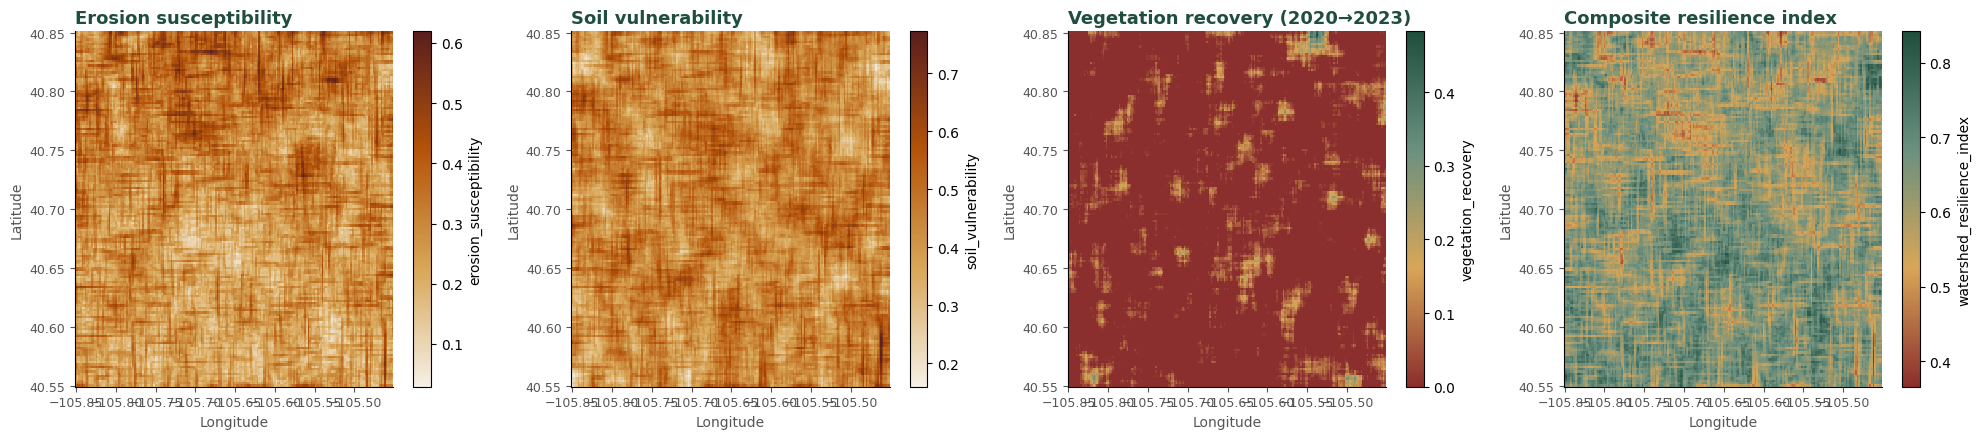

Mean composite resilience: 0.631  (1 = most resilient)
Area-fraction low resilience (<0.4): 0.1%


In [3]:
composite = indicators.watershed_resilience_index(erosion, soil_vuln, veg_recovery)

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
viz.plot_raster(erosion, title="Erosion susceptibility", ax=axes[0], cmap=viz.SEVERITY_CMAP)
viz.plot_raster(soil_vuln, title="Soil vulnerability", ax=axes[1], cmap=viz.SEVERITY_CMAP)
viz.plot_raster(veg_recovery, title="Vegetation recovery (2020→2023)", ax=axes[2])
viz.plot_raster(composite, title="Composite resilience index", ax=axes[3])
plt.tight_layout()
plt.savefig("../outputs/03_composite_resilience.png", dpi=150)
plt.show()

print(f"Mean composite resilience: {float(composite.mean()):.3f}  (1 = most resilient)")
print(f"Area-fraction low resilience (<0.4): {float((composite < 0.4).mean()):.1%}")

## Single-number regional summary (what a cross-region atlas table would show)

In [4]:
import pandas as pd

summary = pd.DataFrame([{
    "region": REGION.name,
    "fire_event": f"{REGION.fire_name} ({REGION.fire_year})",
    "mean_erosion_susceptibility": float(erosion.mean()),
    "mean_soil_vulnerability": float(soil_vuln.mean()),
    "mean_vegetation_recovery": float(veg_recovery.mean()),
    "composite_resilience_index": float(composite.mean()),
}])
summary.round(3)

,region,fire_event,mean_erosion_susceptibility,mean_soil_vulnerability,mean_vegetation_recovery,composite_resilience_index
0,Cache la Poudre Watershed — Cameron Peak Burn ...,Cameron Peak Fire (2020),0.293,0.448,0.015,0.631


## Summary

`composite_resilience_index` is the single number a cross-region atlas
table (Black Hills, Colorado Front Range, Tribal watersheds) would report
per region once Module 2's regional coverage is built out — same function,
new bbox each time. This is the concrete demonstration that Daear's three
application areas (wildfire, soil-watershed, Tribal data sovereignty) are
facets of one underlying resilience-intelligence platform.
